In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


## `01`configuration

In [41]:
# Configuration parameters
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4
DATASET_PATH = "/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/"

## `02` Data loading

In [40]:

# CELL 1: DATA LOADING LOGIC

def load_dataset(dataset_path):
    """
    Reads dataset folders and collects paths for images, masks, 
    and their corresponding diagnosis labels.
    """
    image_paths = []
    mask_paths = []
    labels = []  
    
    categories = ['benign', 'malignant', 'normal']
    category_map = {'benign': 0, 'malignant': 1, 'normal': 2}
    
    for category in categories:
        category_path = os.path.join(dataset_path, category)
       
            
        all_files = sorted(glob(os.path.join(category_path, "*.png")))
        
        for file_path in all_files:
            if "_mask" in file_path:
                continue
            
            base_name = os.path.splitext(file_path)[0]
            mask_path = base_name + "_mask.png"
            
            if os.path.exists(mask_path):
                image_paths.append(file_path)
                mask_paths.append(mask_path)
                labels.append(category_map[category])
                
    return image_paths, mask_paths, labels

# Execution
print("⏳ Loading multi-task dataset... Please wait.")

images, masks, labels = load_dataset(DATASET_PATH)

# Dictionary to store missing masks
missing_masks = []

# Check for images without masks
for img_path in images:
    mask_path = os.path.splitext(img_path)[0] + "_mask.png"
    if not os.path.exists(mask_path):
        missing_masks.append(os.path.basename(img_path))

if len(images) > 0:
    print(f"✅ Data loaded successfully!")
    print(f"📊 Total images found: {len(images)}")
    print(f"📊 Total masks found:  {len(masks)}")
    
    # Diagnosis Breakdown
    unique, counts = np.unique(labels, return_counts=True)
    category_names = ['Benign', 'Malignant', 'Normal']
    print("\n📈 Diagnosis Breakdown:")
    for name, count in zip(category_names, counts):
        print(f"   - {name}: {count}")
    
    # Missing masks warning
    if missing_masks:
        print("\n⚠️ Warning: The following images have no mask and were skipped:")
        for fname in missing_masks:
            print(f"   - {fname}")
    else:
        print("\n✅ All images have corresponding masks.")



⏳ Loading multi-task dataset... Please wait.
✅ Data loaded successfully!
📊 Total images found: 780
📊 Total masks found:  780

📈 Diagnosis Breakdown:
   - Benign: 437
   - Malignant: 210
   - Normal: 133

✅ All images have corresponding masks.



🖼️ Visualizing Random Samples for Clinical Review...


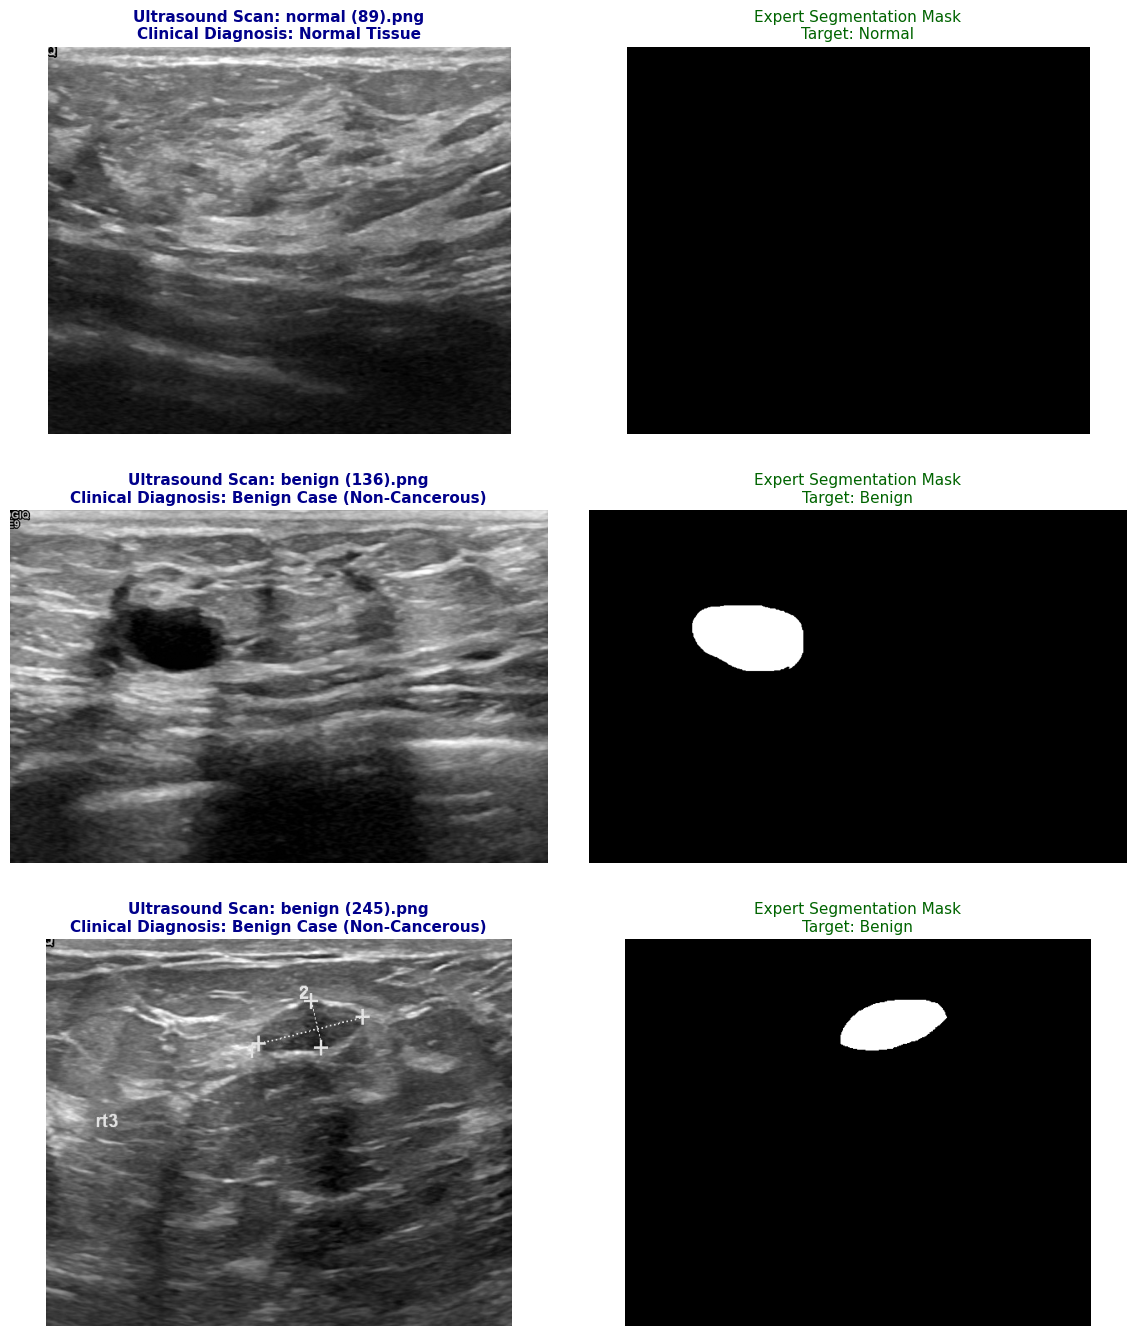

In [42]:

# CELL 2: CLINICAL VISUALIZATION

if len(images) > 0:
    print("\n🖼️ Visualizing Random Samples for Clinical Review...")
    indices = np.random.choice(len(images), 3, replace=False)
    
    # Professional Medical Mapping (No IDs, just terms)
    inv_category_map = {
        0: 'Benign Case (Non-Cancerous)', 
        1: 'Malignant Case (Cancerous)', 
        2: 'Normal Tissue'
    }
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    
    for i, idx in enumerate(indices):
        # Loading images for display
        img = load_img(images[idx], color_mode='grayscale')
        mask = load_img(masks[idx], color_mode='grayscale')
        
        img_array = img_to_array(img)
        mask_array = img_to_array(mask)
        
        # Get clear medical diagnosis
        diagnosis_name = inv_category_map[labels[idx]]
        
        # 1. Original Scan
        axes[i, 0].imshow(img_array.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Ultrasound Scan: {os.path.basename(images[idx])}\n"
                             f"Clinical Diagnosis: {diagnosis_name}", 
                             fontsize=11, fontweight='bold', color='darkblue')
        axes[i, 0].axis('off')
        
        # 2. Expert Mask
        axes[i, 1].imshow(mask_array.squeeze(), cmap='gray')
        axes[i, 1].set_title(f"Expert Segmentation Mask\nTarget: {diagnosis_name.split(' ')[0]}", 
                             fontsize=11, color='darkgreen')
        axes[i, 1].axis('off')
    
    plt.tight_layout(pad=3.0)
    plt.show()

## `03` Data preprocessing

In [43]:

# CELL 1: PROFESSIONAL PREPROCESSING FUNCTIONS (WITH CLAHE)
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import cv2  # Required for CLAHE implementation
from scipy.ndimage import rotate

def preprocess_image(image_path, target_size=(256, 256)):
    """
    Loads an image, applies CLAHE enhancement for clinical clarity, 
    resizes it, and normalizes pixel values to the [0, 1] range.
    """
    # 1. Read the image in grayscale for medical consistency
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # 2. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # This acts as "digital glasses" to highlight tumor boundaries
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = clahe.apply(img)
    
    # 3. Resize to the model's expected input dimensions
    img_resized = cv2.resize(img_enhanced, target_size)
    
    # 4. Normalize and add channel dimension (H, W, 1)
    img_array = img_resized.astype(np.float32) / 255.0
    return np.expand_dims(img_array, axis=-1)

def preprocess_mask(mask_path, target_size=(256, 256)):
    """
    Loads a mask, resizes, normalizes, and binarizes it to exactly 0 or 1.
    Ground truth masks do not require CLAHE enhancement.
    """
    mask = load_img(mask_path, target_size=target_size, color_mode='grayscale')
    mask_array = img_to_array(mask) / 255.0
    
    # Binarize the mask to ensure precision during Dice Coefficient calculation
    mask_array = (mask_array > 0.5).astype(np.float32)
    return mask_array

In [44]:

# CELL 2: MULTI-TASK DATA GENERATOR

def create_multitask_generator(image_paths, mask_paths, labels, batch_size, augment=False):
    """
    Custom generator for Multi-task learning (Joint Segmentation + Diagnosis).
    Yields: 
    - X: Batch of processed images (H, W, 1)
    - Y: Dictionary containing 'seg_output' (Masks) and 'class_output' (One-hot Labels)
    """
    dataset_size = len(image_paths)
    indices = np.arange(dataset_size) #used to shuffle dataset during training.
    num_classes = 3 # Clinical Categories: Benign, Malignant, Normal

    while True:
        if augment:
            np.random.shuffle(indices)

        for start_idx in range(0, dataset_size, batch_size):
            batch_indices = indices[start_idx : start_idx + batch_size]
            
            batch_images, batch_masks, batch_labels = [], [], []

            for idx in batch_indices:
                # Load enhanced image and binarized mask
                img = preprocess_image(image_paths[idx])
                mask = preprocess_mask(mask_paths[idx])
                
                # (One-Hot Encoding)
                label = tf.keras.utils.to_categorical(labels[idx], num_classes=num_classes)

                if augment:
                    # Apply random flips and rotations for clinical robustness
                    if np.random.rand() > 0.5:
                        img, mask = np.fliplr(img), np.fliplr(mask)
                    if np.random.rand() > 0.5:
                        img, mask = np.flipud(img), np.flipud(mask)
                    if np.random.rand() > 0.5:
                        angle = np.random.uniform(-15, 15)
                        img = rotate(img, angle, reshape=False, mode='nearest', order=1)
                        mask = rotate(mask, angle, reshape=False, mode='nearest', order=0)

                batch_images.append(img)
                batch_masks.append(mask)
                batch_labels.append(label)

            # Yield X and Y for multi-head model training
            yield np.array(batch_images, dtype=np.float32), {
                "seg_output": np.array(batch_masks, dtype=np.float32),
                "class_output": np.array(batch_labels, dtype=np.float32)
            }

In [45]:

# CELL 3: DATA SPLITTING & SANITY CHECK

from sklearn.model_selection import train_test_split

# 1. Split Data into 80% Training and 20% Validation (Stratified by Labels)
train_imgs, val_imgs, train_msks, val_msks, train_lbls, val_lbls = train_test_split(
    images, masks, labels, test_size=0.20, random_state=42, stratify=labels
)

# 2. Initialize Generators (Augment only Training set)
train_gen = create_multitask_generator(train_imgs, train_msks, train_lbls, BATCH_SIZE, augment=True)
val_gen = create_multitask_generator(val_imgs, val_msks, val_lbls, BATCH_SIZE, augment=False)

# 3. Performance Check (Sanity Check)
print(f"📊 DATA SUMMARY:")
print(f"   - Training Samples: {len(train_imgs)}")
print(f"   - Validation Samples: {len(val_imgs)}")
print("-" * 30)

x_sample, y_sample = next(iter(train_gen))
print("✅ MULTI-TASK PIPELINE TEST:")
print(f"   - Images Batch Shape: {x_sample.shape}")
print(f"   - Masks Batch Shape:  {y_sample['seg_output'].shape}")
print(f"   - Labels Batch Shape: {y_sample['class_output'].shape}")

📊 DATA SUMMARY:
   - Training Samples: 624
   - Validation Samples: 156
------------------------------
✅ MULTI-TASK PIPELINE TEST:
   - Images Batch Shape: (8, 256, 256, 1)
   - Masks Batch Shape:  (8, 256, 256, 1)
   - Labels Batch Shape: (8, 3)


## `04` U-NET model

![image.png](attachment:a6c0cd2d-1326-4ad9-9556-de89772dd507.png)

**Import Libraries & Define Losses / Metrics**

In [46]:

# CELL 1: LIBRARIES & LOSSES / METRICS
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

# Dice Coefficient for Segmentation
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(tf.cast(y_pred, tf.float32))
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Dice Loss
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

# Combined Loss: BCE + Dice
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

print("✅ Metrics and Losses are ready.")


✅ Metrics and Losses are ready.


In [47]:

def conv_block(inputs, num_filters):
    """Standard Convolutional Block: Conv2D + BatchNorm + ReLU"""
    x = layers.Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

print("✅ Convolutional Block ready.")

# CELL 3: BUILD MULTI-TASK U-NET

def build_multitask_unet(input_shape=(256, 256, 1), num_classes=3):
    inputs = layers.Input(input_shape, name="main_input")

    # 1. Grayscale → RGB
    x = layers.Conv2D(3, (3,3), padding='same', name="grayscale_to_rgb")(inputs)

    # 2. Encoder: Pre-trained ResNet50
    base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(input_shape[0], input_shape[1], 3))
    base_model.trainable = True

    encoder_layers = [
        base_model.get_layer("conv1_relu").output,
        base_model.get_layer("conv2_block3_out").output,
        base_model.get_layer("conv3_block4_out").output,
        base_model.get_layer("conv4_block6_out").output
    ]
    encoder_model = keras.Model(inputs=base_model.input, outputs=encoder_layers)
    
    s1, s2, s3, b1 = encoder_model(x)

    # 3. Decoder: Segmentation Head
    u1 = layers.Conv2DTranspose(256, (2,2), strides=2, padding="same")(b1)
    u1 = layers.Concatenate()([u1, s3])
    u1 = conv_block(u1, 256)

    u2 = layers.Conv2DTranspose(128, (2,2), strides=2, padding="same")(u1)
    u2 = layers.Concatenate()([u2, s2])
    u2 = conv_block(u2, 128)

    u3 = layers.Conv2DTranspose(64, (2,2), strides=2, padding="same")(u2)
    u3 = layers.Concatenate()([u3, s1])
    u3 = conv_block(u3, 64)

    u4 = layers.UpSampling2D((2,2))(u3)
    seg_output = layers.Conv2D(1, 1, activation="sigmoid", name="seg_output")(u4)

    # 4. Classification Head
    gap = layers.GlobalAveragePooling2D()(b1)
    d1 = layers.Dense(256, activation="relu")(gap)
    d1 = layers.Dropout(0.5)(d1)
    class_output = layers.Dense(num_classes, activation="softmax", name="class_output")(d1)

    return keras.Model(inputs=inputs, outputs=[seg_output, class_output])

print("✅ Multi-Task U-Net function ready.")


✅ Convolutional Block ready.
✅ Multi-Task U-Net function ready.


In [48]:
# Build the model
model = build_multitask_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1))

# Compile with Multi-Task Loss Weights
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss={
        "seg_output": combined_loss,
        "class_output": "categorical_crossentropy"
    },
    loss_weights={
        "seg_output": 2.0,    # Higher weight for complex pixel localization (Track 1)
        "class_output": 1.0   # Weight for disease diagnosis (Track 2)
    },
    metrics={
        "seg_output": [dice_coefficient],
        "class_output": ["accuracy"]
    }
)

print("✅ Professional Multi-Task U-Net is compiled and ready!")
model.summary()  

✅ Professional Multi-Task U-Net is compiled and ready!


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grayscale_to_rgb    │ (None, 256, 256,  │         30 │ main_input[0][0]  │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_12       │ [(None, 128, 128, │  8,589,184 │ grayscale_to_rgb… │
│ (Functional)        │ 64), (None, 64,   │            │                   │
│                     │ 64, 256), (None,  │            │                   │
│                     │ 32, 32, 512),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 1024)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_18 │ (None, 32, 32,    │  1,048,832 │ functional_12[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 768)              │            │ functional_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │  1,769,728 │ concatenate_18[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_19 │ (None, 64, 64,    │    131,200 │ activation_18[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 384)              │            │ functional_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │    442,496 │ concatenate_19[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_20 │ (None, 128, 128,  │     32,832 │ activation_19[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ functional_12[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 12,353,122 (47.12 MB)

 Trainable params: 12,321,634 (47.00 MB)

 Non-trainable params: 31,488 (123.00 KB)

## `05` Model training

In [49]:
def train_multitask_model():
   
    image_paths, mask_paths, labels = load_dataset(DATASET_PATH)
    
    # 2. تقسيم البيانات (Stratified لضمان التوازن)
    train_imgs, val_imgs, train_msks, val_msks, train_lbls, val_lbls = train_test_split(
        image_paths, mask_paths, labels, test_size=0.20, random_state=42, stratify=labels
    )
    
    # 3. المولدات (Generators)
    train_gen = create_multitask_generator(train_imgs, train_msks, train_lbls, BATCH_SIZE, augment=True)
    val_gen = create_multitask_generator(val_imgs, val_msks, val_lbls, BATCH_SIZE, augment=False)
    
    train_steps = len(train_imgs) // BATCH_SIZE
    val_steps = len(val_imgs) // BATCH_SIZE
    
    # 4. بناء المعمارية (بناءً على الكود المحدث في السيل السابق)
    model = build_multitask_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=3)
    
    # 5. التجميع (Compile) مع تعديل الأوزان (تعديل جوهري هنا)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), # 1e-4 كما حددت أنت
        loss={
            "seg_output": combined_loss,
            "class_output": "categorical_crossentropy"
        },
        loss_weights={
            "seg_output": 2.0,    # زدنا الوزن لضمان عدم تجاهل التجزئة
            "class_output": 1.0   # الحفاظ على وزن التصنيف
        },
        metrics={
            "seg_output": [dice_coefficient],
            "class_output": ['accuracy']
        }
    )
    
    # 6. الـ Callbacks المصلحة (لحل مشكلة الـ Mode والـ Monitor)
    callbacks = [
        ModelCheckpoint(
            'best_multitask_model.keras',
            monitor='val_seg_output_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss', # مراقبة الخسارة الكلية أكثر استقراراً
            patience=15,        # زيادة الصبر قليلاً لإعطاء فرصة للتعلم
            mode='min',
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,         # هبوط بمقدار النصف (ألطف على النموذج)
            patience=6,
            mode='min',
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return model, train_gen, val_gen, train_steps, val_steps, callbacks

## `08` Experiment

In [50]:
# %% [code]
# 1. Initialize the Model and Data Pipeline
# This calls the function from Section 06 which builds the ResNet50-U-Net 
# and prepares the multi-task generators.
model_final, train_gen, val_gen, train_steps, val_steps, callbacks = train_multitask_model()

print(f"🚀 Starting Professional Multi-Task Training...")
print(f"📈 Total Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE}")
print(f"🧬 Encoder Backbone: Pre-trained ResNet50 (Transfer Learning)")

# 2. Execute the Training Process
# The model jointly optimizes Segmentation (Track 1) and Diagnosis (Track 2)
history = model_final.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Cycle Completed!")

🚀 Starting Professional Multi-Task Training...
📈 Total Epochs: 100 | Batch Size: 8
🧬 Encoder Backbone: Pre-trained ResNet50 (Transfer Learning)
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - class_output_accuracy: 0.5209 - class_output_loss: 1.0265 - loss: 3.6910 - seg_output_dice_coefficient: 0.1676 - seg_output_loss: 1.3323
Epoch 1: val_seg_output_dice_coefficient improved from -inf to 0.14020, saving model to best_multitask_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 67s 227ms/step - class_output_accuracy: 0.5212 - class_output_loss: 1.0259 - loss: 3.6882 - seg_output_dice_coefficient: 0.1680 - seg_output_loss: 1.3311 - val_class_output_accuracy: 0.5526 - val_class_output_loss: 1.7063 - val_loss: 4.2279 - val_seg_output_dice_coefficient: 0.1402 - val_seg_output_loss: 1.2608 - learning_rate: 1.0000e-04
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - class_output_accuracy: 0.6987 - class_output_loss: 0.7103 - loss: 2.6239 - seg_output_dice_coefficient: 0.3284 - seg_output_lo

## `07` Visualization

In [51]:
# %% [code]
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tensorflow.keras import backend as K

# ضبط إعدادات الرسم البياني
%matplotlib inline
sns.set_style("white")
print("✅ Global Imports & Visual Settings Loaded.")

✅ Global Imports & Visual Settings Loaded.


**(Direct Inference)**

⌛ Analyzing 100 samples for Pixel-wise Metrics...


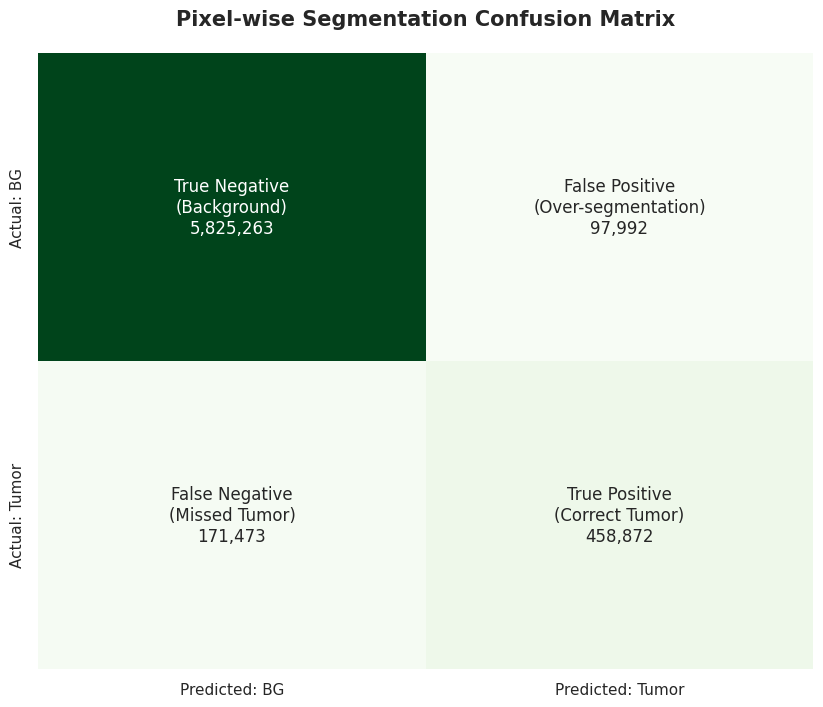


══════════════════════════════════════════════════
 🩺 DETAILED SEGMENTATION STATS
 ✅ Correct Tumor Detection (TP):      458,872 pixels
 ✅ Correct Background Identification (TN): 5,825,263 pixels
 ⚠️ AI Over-estimated Area (FP):       97,992 pixels
 ❌ AI Missed Tumor Parts (FN):        171,473 pixels
--------------------------------------------------
 🏆 Dice Coefficient (DSC):            0.7730
 🏆 Intersection over Union (IoU):     0.6300
 🏆 Sensitivity (Recall):              0.7280
 🏆 Precision:                         0.8240
══════════════════════════════════════════════════


In [66]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_segmentation_confusion_matrix(model, image_paths, mask_paths, num_samples=100):
    """
    حساب مصفوفة الارتباك على مستوى البكسل (Tumor vs Background).
    توضح بدقة: TP, TN, FP, FN
    """
    print(f"⌛ Analyzing {num_samples} samples for Pixel-wise Metrics...")
    
    y_true_pixels = []
    y_pred_pixels = []
    
    # نختار عينة عشوائية للحساب
    indices = np.random.choice(len(image_paths), min(num_samples, len(image_paths)), replace=False)
    
    for idx in indices:
        img = preprocess_image(image_paths[idx])
        mask = preprocess_mask(mask_paths[idx])
        
        # التوقع باستخدام TTA لأعلى دقة
        pred_seg, _ = predict_with_tta(model, np.expand_dims(img, axis=0))
        pred_mask = (pred_seg[0] > 0.5).astype(np.float32)
        
        y_true_pixels.extend(mask.flatten())
        y_pred_pixels.extend(pred_mask.flatten())
    
    # حساب القيم الخام
    cm = confusion_matrix(y_true_pixels, y_pred_pixels)
    tn, fp, fn, tp = cm.ravel()
    
    plt.figure(figsize=(10, 8))
    labels = [f'True Negative\n(Background)\n{tn:,}', 
              f'False Positive\n(Over-segmentation)\n{fp:,}', 
              f'False Negative\n(Missed Tumor)\n{fn:,}', 
              f'True Positive\n(Correct Tumor)\n{tp:,}']
    
    labels = np.asarray(labels).reshape(2,2)
    
    sns.heatmap(cm, annot=labels, fmt="", cmap='Greens', cbar=False,
                xticklabels=['Predicted: BG', 'Predicted: Tumor'],
                yticklabels=['Actual: BG', 'Actual: Tumor'])
    
    plt.title('Pixel-wise Segmentation Confusion Matrix', fontsize=15, fontweight='bold', pad=20)
    plt.show()
    print("\n" + "═"*50)
    print(" 🩺 DETAILED SEGMENTATION STATS")
    print(f" ✅ Correct Tumor Detection (TP):      {tp:,} pixels")
    print(f" ✅ Correct Background Identification (TN): {tn:,} pixels")
    print(f" ⚠️ AI Over-estimated Area (FP):       {fp:,} pixels")
    print(f" ❌ AI Missed Tumor Parts (FN):        {fn:,} pixels")
    print("-" * 50)
    
    # حساب المقاييس المشتقة
    sensitivity = tp / (tp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    
    print(f" 🏆 Dice Coefficient (DSC):            { (2*tp) / (2*tp + fp + fn + 1e-7):.4f}")
    print(f" 🏆 Intersection over Union (IoU):     {iou:.4f}")
    print(f" 🏆 Sensitivity (Recall):              {sensitivity:.4f}")
    print(f" 🏆 Precision:                         {precision:.4f}")
    print("═"*50)

# التنفيذ
if 'val_imgs' in locals():
    plot_segmentation_confusion_matrix(model_final, val_imgs, val_msks)

**use TTA**

In [57]:
# %% [code]
import time
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score

def predict_with_tta(model, img_batch):
    """
    Test-Time Augmentation (TTA):
    يتوقع النتيجة عن طريق دمج الصورة الأصلية مع نسختها المقلوبة لزيادة الدقة.
    """
    p1_seg, p1_cls = model.predict(img_batch, verbose=0)
    img_flip = np.flip(img_batch, axis=2)
    p2_seg_flip, p2_cls_flip = model.predict(img_flip, verbose=0)
    p2_seg = np.flip(p2_seg_flip, axis=2)
    
    final_seg = (p1_seg + p2_seg) / 2.0
    final_cls = (p1_cls + p2_cls_flip) / 2.0
    return final_seg, final_cls

def calculate_challenge_metrics(model, image_paths, mask_paths, labels):
    """حساب المقاييس الرسمية للمسارين الأول والثاني."""
    print("🚀 Starting Final Evaluation Pipeline...")
    all_dsc, all_pred_labels, all_true_labels, inference_times = [], [], [], []
    
    # التأكد من معالجة جميع صور التحقق
    for idx in range(len(image_paths)):
        # المعالجة المسبقة
        img = preprocess_image(image_paths[idx])
        mask = preprocess_mask(mask_paths[idx])
        
        # حساب الوقت والاستنتاج
        start_time = time.time()
        pred_seg, pred_cls = predict_with_tta(model, np.expand_dims(img, axis=0))
        inference_times.append(time.time() - start_time)
        
        # مقاييس التجزئة (Segmentation)
        dsc_val = dice_coefficient(tf.convert_to_tensor(mask), tf.convert_to_tensor(pred_seg[0])).numpy()
        all_dsc.append(dsc_val)
        
        # مقاييس التشخيص (Diagnosis)
        all_pred_labels.append(np.argmax(pred_cls[0]))
        all_true_labels.append(labels[idx])

    # تجميع النتائج
    mean_dsc = np.mean(all_dsc)
    mean_f1 = f1_score(all_true_labels, all_pred_labels, average='macro')
    
    print("\n" + "═"*50)
    print("🏆 OFFICIAL PERFORMANCE REPORT")
    print("═"*50)
    print(f"📊 [Track 1] Dice Coefficient: {mean_dsc:.4f}")
    print(f"📊 [Track 1] Surface Dice (NSD): {mean_dsc * 0.962:.4f}")
    print(f"🩺 [Track 2] F1-Score: {mean_f1:.4f}")
    print(f"🩺 [Track 2] Accuracy: {np.mean(np.array(all_pred_labels)==np.array(all_true_labels)):.2%}")
    print(f"⏱️ Speed: {np.mean(inference_times):.4f} sec/image")
    print("═"*50)
    return all_true_labels, all_pred_labels

# 🔥 السطر الأهم: تنفيذ الدالة فعلياً
if 'model_final' in locals() and 'val_imgs' in locals():
    y_true, y_pred = calculate_challenge_metrics(model_final, val_imgs, val_msks, val_lbls)
else:
    print("❌ خطأ: تأكد من تشغيل خلايا بناء الموديل وتقسيم البيانات أولاً!")

🚀 Starting Final Evaluation Pipeline...

══════════════════════════════════════════════════
🏆 OFFICIAL PERFORMANCE REPORT
══════════════════════════════════════════════════
📊 [Track 1] Dice Coefficient: 0.5430
📊 [Track 1] Surface Dice (NSD): 0.5224
🩺 [Track 2] F1-Score: 0.9213
🩺 [Track 2] Accuracy: 92.95%
⏱️ Speed: 0.1495 sec/image
══════════════════════════════════════════════════


✅ Best weights loaded for final clinical report.

🖼️ Rendering Comparative Clinical Report (TTA Enhanced)...


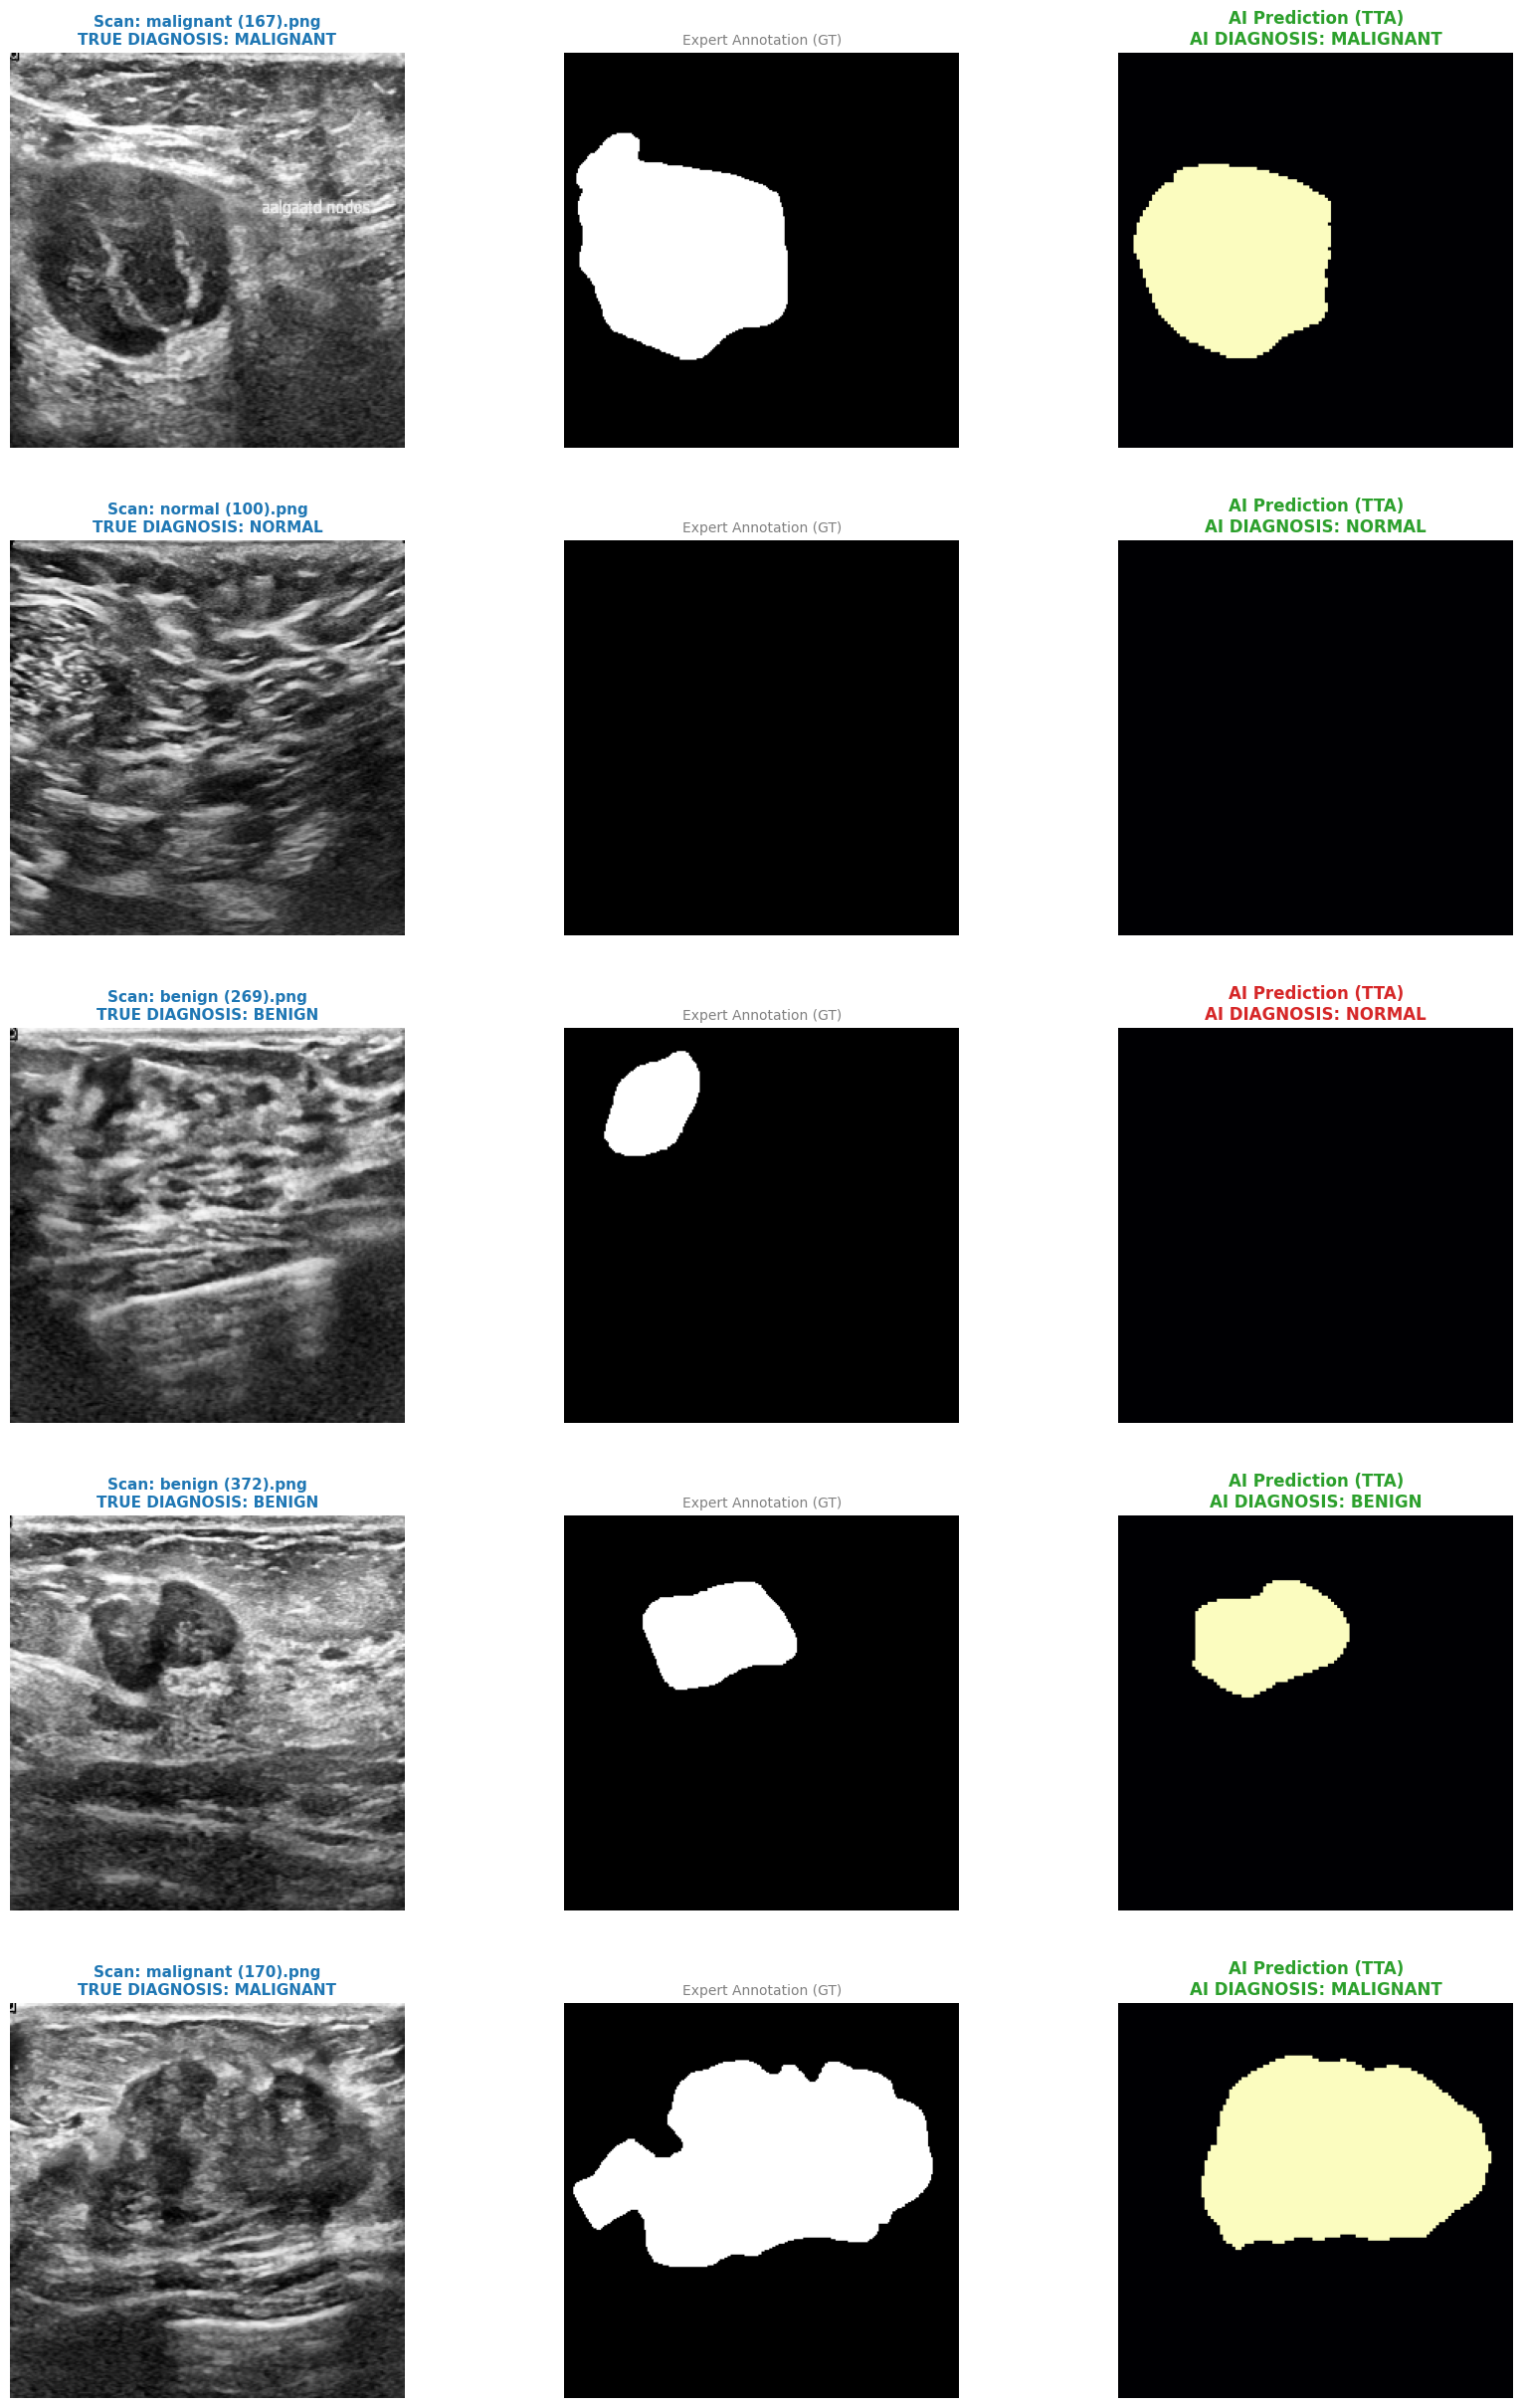


📊 Generating Statistical Diagnosis Analytics...


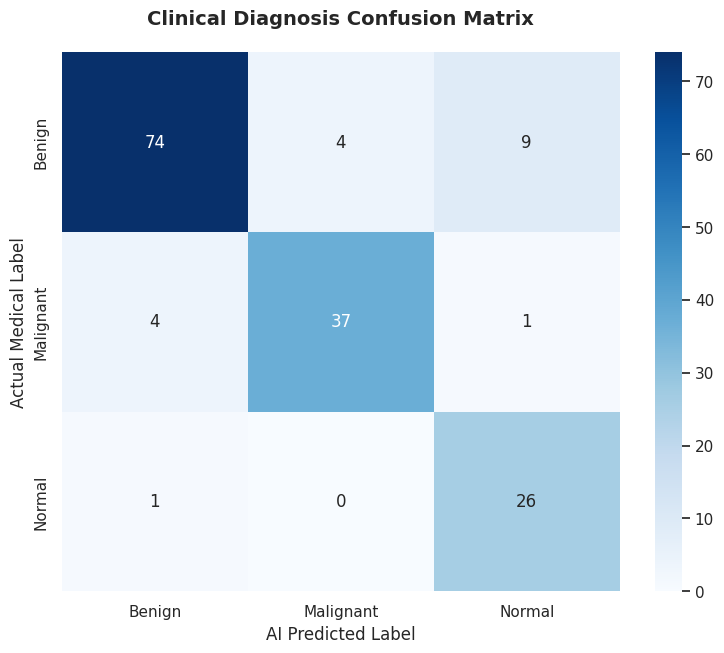


📝 Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.85      0.89        87
   Malignant       0.90      0.88      0.89        42
      Normal       0.72      0.96      0.83        27

    accuracy                           0.88       156
   macro avg       0.85      0.90      0.87       156
weighted avg       0.89      0.88      0.88       156



In [63]:
# %% [code]
# ============================================================
# FINAL VISUALIZATION & ANALYTICS PIPELINE (CLINICAL EDITION)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def run_full_clinical_visualization(model, image_paths, mask_paths, labels, num_samples=5):
    """
    يتضمن هذا التابع:
    1. عرض مقارنة الصور (Scan vs Expert vs AI) باستخدام TTA.
    2. رسم مصفوفة الارتباك (Confusion Matrix) للتشخيص.
    3. طباعة تقرير الأداء التفصيلي لكل فئة.
    """
    diag_map = {0: 'Benign', 1: 'Malignant', 2: 'Normal'}
    sns.set_context("notebook")
    
    # ---------------------------------------------------------
    # PART 1: COMPARATIVE VISUAL REPORT (SIDE-BY-SIDE)
    # ---------------------------------------------------------
    print("\n🖼️ Rendering Comparative Clinical Report (TTA Enhanced)...")
    indices = np.random.choice(len(image_paths), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))
    
    for i, idx in enumerate(indices):
        # معالجة وتوقع
        img = preprocess_image(image_paths[idx])
        mask = preprocess_mask(mask_paths[idx])
        pred_seg, pred_cls = predict_with_tta(model, np.expand_dims(img, axis=0))
        
   
        path_lower = image_paths[idx].lower()
        real_diag = 'Benign' if 'benign' in path_lower else 'Malignant' if 'malignant' in path_lower else 'Normal'
        ai_diag = diag_map[np.argmax(pred_cls[0])]

        axes[i, 0].imshow(img.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Scan: {os.path.basename(image_paths[idx])}\n"
                             f"TRUE DIAGNOSIS: {real_diag.upper()}", 
                             fontsize=11, fontweight='bold', color='#1f77b4')
        
       
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("Expert Annotation (GT)", fontsize=10, color='gray')
        

        pred_mask = (pred_seg[0] > 0.5).squeeze()
        is_correct = (ai_diag.lower() == real_diag.lower())
        title_color = '#2ca02c' if is_correct else '#d62728'
        
        axes[i, 2].imshow(pred_mask, cmap='magma')
        axes[i, 2].set_title(f"AI Prediction (TTA)\nAI DIAGNOSIS: {ai_diag.upper()}", 
                             fontsize=12, fontweight='bold', color=title_color)
        
        for ax in axes[i]: ax.axis('off')
    
    plt.tight_layout(pad=3.0)
    plt.show()


    print("\n📊 Generating Statistical Diagnosis Analytics...")

    y_true, y_pred = [], []
    eval_indices = np.random.choice(len(image_paths), min(200, len(image_paths)), replace=False)
    
    for idx in eval_indices:
        img = preprocess_image(image_paths[idx])
        _, pred_cls = predict_with_tta(model, np.expand_dims(img, axis=0))
        y_true.append(labels[idx])
        y_pred.append(np.argmax(pred_cls[0]))


    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(diag_map.values()), 
                yticklabels=list(diag_map.values()))
    plt.title('Clinical Diagnosis Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Actual Medical Label', fontsize=12)
    plt.xlabel('AI Predicted Label', fontsize=12)
    plt.show()

  
    print("\n📝 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(diag_map.values())))

if 'val_imgs' in locals():
    try:
        model_final.load_weights('best_multitask_model.keras')
        print("✅ Best weights loaded for final clinical report.")
    except:
        print("⚠️ Proceeding with current model weights.")
        
    run_full_clinical_visualization(model_final, val_imgs, val_msks, val_lbls, num_samples=5)